# Reading Hadley SST data

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

In [3]:
# read in the data
input_path = '../../../Data/HadISST/HadISST_sst.nc'
ds = xr.open_dataset(input_path)

In [4]:
ds

<xarray.Dataset> Size: 480MB
Dimensions:    (time: 1851, nv: 2, latitude: 180, longitude: 360)
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.525486592 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Dimensions without coordinates: nv
Data variables:
    time_bnds  (time, nv) float32 15kB ...
    sst        (time, latitude, longitude) float32 480MB ...
Attributes:
    Title:                      Monthly version of HadISST sea surface temper...
    description:                HadISST 1.1 monthly average sea surface tempe...
    institution:                Met Office Hadley Centre
    source:                     HadISST
    reference:                  Rayner, N. A., Parker, D. E., Horton, E. B., ...
    Conventions:                CF-1.0
    history:                    10/5/2024 converted to netcdf from pp format
    supplementary_information:  Updates and supplementary information will be...
    comment:                    Data restrictions: for academic research use ...

In [21]:
ds.sst

<xarray.DataArray 'sst' (time: 1851, latitude: 180, longitude: 360)> Size: 480MB
[119944800 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 15kB 1870-01-16T11:59:59.525486592 ... 2...
  * latitude   (latitude) float32 720B 89.5 88.5 87.5 86.5 ... -87.5 -88.5 -89.5
  * longitude  (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

In [17]:
# select only the area of the islands
# and data from 1980 until 2023
galapagos = ds.sst.sel(latitude=slice(2,-2), longitude=slice(-92,-88), time=slice('1980','2023'))
galapagos

<xarray.DataArray 'sst' (time: 528, latitude: 4, longitude: 4)> Size: 34kB
[8448 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 4kB 1980-01-16T12:03:12.563085312 ... 20...
  * latitude   (latitude) float32 16B 1.5 0.5 -0.5 -1.5
  * longitude  (longitude) float32 16B -91.5 -90.5 -89.5 -88.5
Attributes:
    standard_name:  sea_surface_temperature
    long_name:      sst
    units:          C
    cell_methods:   time: lat: lon: mean

In [23]:
galapagos.min(), galapagos.max(), galapagos.mean()

(<xarray.DataArray 'sst' ()> Size: 4B
 array(19.25843, dtype=float32),
 <xarray.DataArray 'sst' ()> Size: 4B
 array(30.189915, dtype=float32),
 <xarray.DataArray 'sst' ()> Size: 4B
 array(24.559172, dtype=float32))

In [18]:
# get mean SST for entire area of the islands maintaining time dimension
# not weighted by latitude since grid squares should have very similar areas
galapagos_mean = galapagos.mean(dim=['latitude','longitude'])
galapagos_mean

<xarray.DataArray 'sst' (time: 528)> Size: 2kB
array([25.244114, 26.096855, 26.334497, 25.990839, 25.520142, 24.002472,
       22.949047, 22.162294, 23.307873, 22.680197, 23.46553 , 23.279598,
       24.53672 , 25.915453, 26.879303, 26.077457, 25.339275, 24.190739,
       22.961193, 22.193525, 22.576458, 22.703651, 22.861069, 24.349672,
       25.389523, 26.684479, 26.535177, 26.11256 , 25.487907, 24.598164,
       24.174614, 24.175293, 24.921913, 25.469   , 26.565746, 27.451653,
       28.452877, 28.934843, 29.708454, 29.810669, 29.241112, 28.27536 ,
       26.869364, 25.533516, 24.385847, 23.457924, 23.293045, 23.568367,
       24.37804 , 25.259497, 26.143589, 25.978077, 23.619469, 22.440598,
       22.543663, 22.113697, 22.167349, 22.236834, 23.222404, 23.10759 ,
       24.050924, 25.049255, 25.628414, 25.687042, 23.250935, 22.584747,
       22.464127, 21.628761, 22.141323, 22.137253, 22.74491 , 23.518368,
       24.92326 , 26.362694, 26.13382 , 25.876436, 24.449389, 23.364597,
       23.47166 , 22.78929 , 22.77295 , 23.478313, 24.157017, 24.895164,
       26.617983, 27.890076, 28.28176 , 28.039516, 26.901403, 25.009342,
       24.641754, 23.766563, 24.153759, 24.094341, 24.233063, 24.871883,
       25.408836, 25.914446, 25.971169, 24.840023, 23.351028, 21.399794,
       21.484589, 21.264297, 21.405802, 21.884815, 22.777454, 22.922543,
       24.940716, 26.428074, 26.003342, 25.741854, 23.892902, 23.323751,
       23.020922, 22.435213, 22.37278 , 22.659637, 22.904694, 23.61097 ,
...
       24.277071, 23.306494, 23.211174, 23.473026, 24.229511, 24.556572,
       25.440994, 26.320103, 26.729412, 27.219868, 26.574612, 26.647823,
       25.851616, 25.056797, 25.38621 , 25.816452, 26.24958 , 26.880772,
       27.839504, 28.122341, 28.336031, 26.516865, 25.404135, 23.668104,
       22.478638, 22.093447, 22.529871, 22.459146, 23.205883, 23.464916,
       25.34552 , 27.479794, 27.5726  , 26.563696, 25.134819, 24.038864,
       23.02602 , 21.989016, 21.413269, 21.675432, 21.999538, 22.46294 ,
       23.621817, 26.110483, 25.668432, 25.809141, 25.01828 , 24.29177 ,
       23.5405  , 22.347471, 22.878248, 23.755169, 24.416794, 25.190239,
       26.393139, 27.895678, 26.583141, 27.304878, 25.464989, 23.85752 ,
       22.843388, 22.595533, 22.080011, 22.456024, 23.49854 , 23.854702,
       25.505081, 27.13679 , 26.343409, 26.256859, 24.667244, 23.223745,
       22.426296, 22.11367 , 22.200058, 22.454708, 23.274828, 23.561234,
       24.812279, 26.08258 , 26.343914, 25.315153, 24.663237, 24.000254,
       23.465118, 22.992899, 22.445084, 22.598965, 22.778421, 22.937786,
       24.514917, 25.567848, 26.434067, 25.748077, 24.47892 , 23.360277,
       23.218184, 23.035465, 22.112862, 21.996246, 22.710619, 23.259537,
       25.112879, 26.649334, 27.710733, 28.371521, 26.969736, 26.236885,
       26.02694 , 25.773954, 24.858803, 25.092102, 25.69095 , 25.78241 ],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-16T12:03:12.563085312 ... 2023...

<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
/var/folders/x9/4cv754f12hv2bf6s__9xrzj80000gp/T/ipykernel_64212/1921011444.py:4: SyntaxWarning: invalid escape sequence '\c'
  plt.ylabel("SST ($^\circ C$)")


Text(0, 0.5, 'SST ($^\\circ C$)')

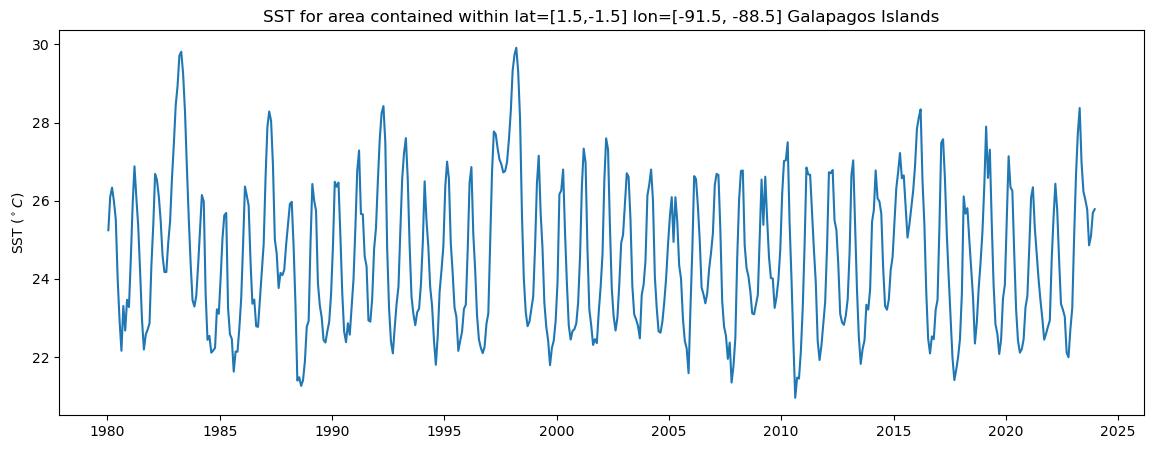

In [24]:
plt.figure(figsize=(14,5))
plt.plot(galapagos_mean.time, galapagos_mean)
plt.title("SST for area contained within lat=[1.5,-1.5] lon=[-91.5, -88.5] Galapagos Islands")
plt.ylabel("SST ($^\circ C$)")